In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Το μοντέλο θα τρέξει σε: {device}")

BATCH_SIZE = 64

# CIFAR-10: 3 Κανάλια (RGB), 32x32 pixels
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Αφήνουμε το Mirror Fix ενεργό, καλού-κακού, για σταθερότητα
datasets.CIFAR10.url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz" # Using a known working mirror for CIFAR-10

print("Κατέβασμα δεδομένων CIFAR-10...")
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

Το μοντέλο θα τρέξει σε: cuda
Κατέβασμα δεδομένων CIFAR-10...


100%|██████████| 170M/170M [06:25<00:00, 442kB/s]


In [5]:
def get_task_data(dataset, classes):
    targets = np.array(dataset.targets)
    mask = np.isin(targets, classes)
    indices = np.where(mask)[0]
    return Subset(dataset, indices)

# Οι 10 κλάσεις του CIFAR: 0:airplane, 1:auto, 2:bird, 3:cat, 4:deer, 5:dog, 6:frog, 7:horse, 8:ship, 9:truck
tasks = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
train_loaders, test_loaders = [], []

for task_classes in tasks:
    train_loaders.append(DataLoader(get_task_data(train_dataset, task_classes), batch_size=BATCH_SIZE, shuffle=True))
    test_loaders.append(DataLoader(get_task_data(test_dataset, task_classes), batch_size=BATCH_SIZE, shuffle=False))

print("Το Split CIFAR-10 είναι έτοιμο!")

Το Split CIFAR-10 είναι έτοιμο!


In [6]:
# --- 1. ΒΑΣΙΚΟ CNN ΓΙΑ NAIVE ΚΑΙ BUFFER (Ενισχυμένο για CIFAR) ---
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # Μετά από 3 poolings (32x32 -> 16x16 -> 8x8 -> 4x4)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 128 * 4 * 4)
        return self.fc2(F.relu(self.fc1(x)))

# --- 2. PROGRESSIVE NEURAL NETWORKS (PNN - Ενισχυμένο) ---
class PNN(nn.Module):
    # Είσοδος: 3 channels * 32 * 32 = 3072, με μεγαλύτερα Hidden Layers
    def __init__(self, layer_sizes=[3 * 32 * 32, 1024, 512, 256, 10]):
        super(PNN, self).__init__()
        self.layer_sizes = layer_sizes
        self.n_tasks = 0
        self.columns = nn.ModuleList()
        self.lateral = nn.ModuleDict()

    def add_task(self):
        self.n_tasks += 1
        task_idx = self.n_tasks - 1
        col = nn.ModuleList([nn.Linear(self.layer_sizes[i], self.layer_sizes[i+1]) for i in range(len(self.layer_sizes) - 1)])
        self.columns.append(col)

        if task_idx > 0:
            for l in range(1, len(self.layer_sizes) - 1):
                for prev_t in range(task_idx):
                    self.lateral[f"t{task_idx}_l{l}_prev{prev_t}"] = nn.Linear(self.layer_sizes[l], self.layer_sizes[l+1])

    def freeze_columns(self, up_to_task):
        for t in range(up_to_task):
            for param in self.columns[t].parameters(): param.requires_grad = False
        for k, v in self.lateral.items():
            if int(k.split('_')[0][1:]) < up_to_task:
                for param in v.parameters(): param.requires_grad = False

    def forward(self, x, task_id):
        x = x.view(-1, 3 * 32 * 32)
        activations = [[x] for _ in range(task_id + 1)]
        for l in range(len(self.layer_sizes) - 1):
            for t in range(task_id + 1):
                out = self.columns[t][l](activations[t][l])
                if l > 0 and t > 0:
                    for prev_t in range(t):
                        out += self.lateral[f"t{t}_l{l}_prev{prev_t}"](activations[prev_t][l])
                if l < len(self.layer_sizes) - 2: out = F.relu(out)
                activations[t].append(out)
        return activations[task_id][-1]

# --- 3. ΣΥΝΑΡΤΗΣΕΙΣ ΑΞΙΟΛΟΓΗΣΗΣ ---
criterion = nn.CrossEntropyLoss()

def evaluate_model(model, test_loaders, current_task_idx):
    model.eval()
    accuracies = []
    with torch.no_grad():
        for i in range(current_task_idx + 1):
            correct, total = 0, 0
            for data, target in test_loaders[i]:
                data, target = data.to(device), target.to(device)
                _, pred = torch.max(model(data), 1)
                total += target.size(0); correct += (pred == target).sum().item()
            accuracies.append(100 * correct / total)
    return accuracies

def evaluate_model_pnn(model, test_loaders, current_task_idx):
    model.eval()
    accuracies = []
    with torch.no_grad():
        for i in range(current_task_idx + 1):
            correct, total = 0, 0
            for data, target in test_loaders[i]:
                outputs = model(data.to(device), task_id=i)
                _, predicted = torch.max(outputs.data, 1)
                total += target.size(0)
                correct += (predicted == target.to(device)).sum().item()
            accuracies.append(100 * correct / total)
    return accuracies

def calculate_forgetting(acc_matrix):
    f = []
    for j in range(4):
        max_past = max([acc_matrix[i][j] for i in range(j, 4)])
        f.append(max_past - acc_matrix[4][j])
    return np.mean(f) if f else 0

In [7]:
print("\n=== ΕΚΤΕΛΕΣΗ 1/3: NAIVE APPROACH ===")
naive_classifier = CNNClassifier().to(device)
opt_naive = optim.Adam(naive_classifier.parameters(), lr=0.001)
naive_acc_matrix = []

EPOCHS_NAIVE = 5

for task_idx, train_loader in enumerate(train_loaders):
    print(f"---> Εκπαίδευση NAIVE στο Task {task_idx + 1}...")
    naive_classifier.train()

    for epoch in range(EPOCHS_NAIVE):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            opt_naive.zero_grad()
            loss = criterion(naive_classifier(data), target)
            loss.backward()
            opt_naive.step()

    accs = evaluate_model(naive_classifier, test_loaders, task_idx)
    naive_acc_matrix.append(accs)
    print(f"Αποτελέσματα: {[round(a, 2) for a in accs]}")


=== ΕΚΤΕΛΕΣΗ 1/3: NAIVE APPROACH ===
---> Εκπαίδευση NAIVE στο Task 1...
Αποτελέσματα: [95.05]
---> Εκπαίδευση NAIVE στο Task 2...
Αποτελέσματα: [0.0, 80.2]
---> Εκπαίδευση NAIVE στο Task 3...
Αποτελέσματα: [0.0, 0.0, 86.05]
---> Εκπαίδευση NAIVE στο Task 4...
Αποτελέσματα: [0.0, 0.0, 0.0, 94.65]
---> Εκπαίδευση NAIVE στο Task 5...
Αποτελέσματα: [0.0, 0.0, 0.0, 0.0, 89.0]


In [11]:
print("\n=== ΕΚΤΕΛΕΣΗ 2/3: MEMORY BUFFER ===")
buffer_classifier = CNNClassifier().to(device)
opt_buffer = optim.Adam(buffer_classifier.parameters(), lr=0.001)
buffer_acc_matrix = []
memory_data, memory_targets = [], []

SAMPLES_PER_TASK = 2000

for task_idx, train_loader in enumerate(train_loaders):
    print(f"---> Εκπαίδευση BUFFER στο Task {task_idx + 1}...")
    buffer_classifier.train()

    task_d, task_t = [], []
    for d, t in train_loader:
        task_d.append(d)
        task_t.append(t)
    memory_data.append(torch.cat(task_d)[:SAMPLES_PER_TASK])
    memory_targets.append(torch.cat(task_t)[:SAMPLES_PER_TASK])

    for epoch in range(EPOCHS_NAIVE):
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            if task_idx > 0:
                old_d = torch.cat(memory_data[:task_idx]).to(device)
                old_t = torch.cat(memory_targets[:task_idx]).to(device)
                idx = torch.randperm(len(old_d))[:len(data)]
                data = torch.cat([data, old_d[idx]])
                target = torch.cat([target, old_t[idx]])

            opt_buffer.zero_grad()
            loss = criterion(buffer_classifier(data), target)
            loss.backward()
            opt_buffer.step()

    accs = evaluate_model(buffer_classifier, test_loaders, task_idx)
    buffer_acc_matrix.append(accs)
    print(f"Αποτελέσματα: {[round(a, 2) for a in accs]}")


=== ΕΚΤΕΛΕΣΗ 2/3: MEMORY BUFFER ===
---> Εκπαίδευση BUFFER στο Task 1...
Αποτελέσματα: [93.5]
---> Εκπαίδευση BUFFER στο Task 2...
Αποτελέσματα: [83.0, 79.65]
---> Εκπαίδευση BUFFER στο Task 3...
Αποτελέσματα: [80.45, 49.3, 75.2]
---> Εκπαίδευση BUFFER στο Task 4...
Αποτελέσματα: [82.1, 43.35, 48.95, 88.15]
---> Εκπαίδευση BUFFER στο Task 5...
Αποτελέσματα: [59.15, 42.4, 60.55, 69.15, 86.0]


In [9]:
print("\n=== ΕΚΤΕΛΕΣΗ 3/3: PROGRESSIVE NEURAL NETWORKS (PNN) ===")

pnn_model = PNN().to(device)
pnn_acc_matrix = []
EPOCHS_PER_TASK = 5

for task_idx, train_loader in enumerate(train_loaders):
    print(f"\n---> Εκπαίδευση στο Task {task_idx + 1} (Κλάσεις {tasks[task_idx]})...")

    pnn_model.add_task()
    pnn_model.to(device)
    pnn_model.freeze_columns(up_to_task=task_idx)

    optimizer_pnn = optim.Adam(filter(lambda p: p.requires_grad, pnn_model.parameters()), lr=0.001)
    pnn_model.train()

    for epoch in range(EPOCHS_PER_TASK):
        for data, target in train_loader:
            optimizer_pnn.zero_grad()
            outputs = pnn_model(data.to(device), task_id=task_idx)
            loss = criterion(outputs, target.to(device))
            loss.backward()
            optimizer_pnn.step()

    accs = evaluate_model_pnn(pnn_model, test_loaders, task_idx)
    pnn_acc_matrix.append(accs)
    print(f" -> Ακρίβεια στα μέχρι τώρα tasks: {[round(a, 2) for a in accs]}")


=== ΕΚΤΕΛΕΣΗ 3/3: PROGRESSIVE NEURAL NETWORKS (PNN) ===

---> Εκπαίδευση στο Task 1 (Κλάσεις [0, 1])...
 -> Ακρίβεια στα μέχρι τώρα tasks: [89.7]

---> Εκπαίδευση στο Task 2 (Κλάσεις [2, 3])...
 -> Ακρίβεια στα μέχρι τώρα tasks: [89.7, 76.0]

---> Εκπαίδευση στο Task 3 (Κλάσεις [4, 5])...
 -> Ακρίβεια στα μέχρι τώρα tasks: [89.7, 76.0, 79.0]

---> Εκπαίδευση στο Task 4 (Κλάσεις [6, 7])...
 -> Ακρίβεια στα μέχρι τώρα tasks: [89.7, 76.0, 79.0, 89.25]

---> Εκπαίδευση στο Task 5 (Κλάσεις [8, 9])...
 -> Ακρίβεια στα μέχρι τώρα tasks: [89.7, 76.0, 79.0, 89.25, 84.9]


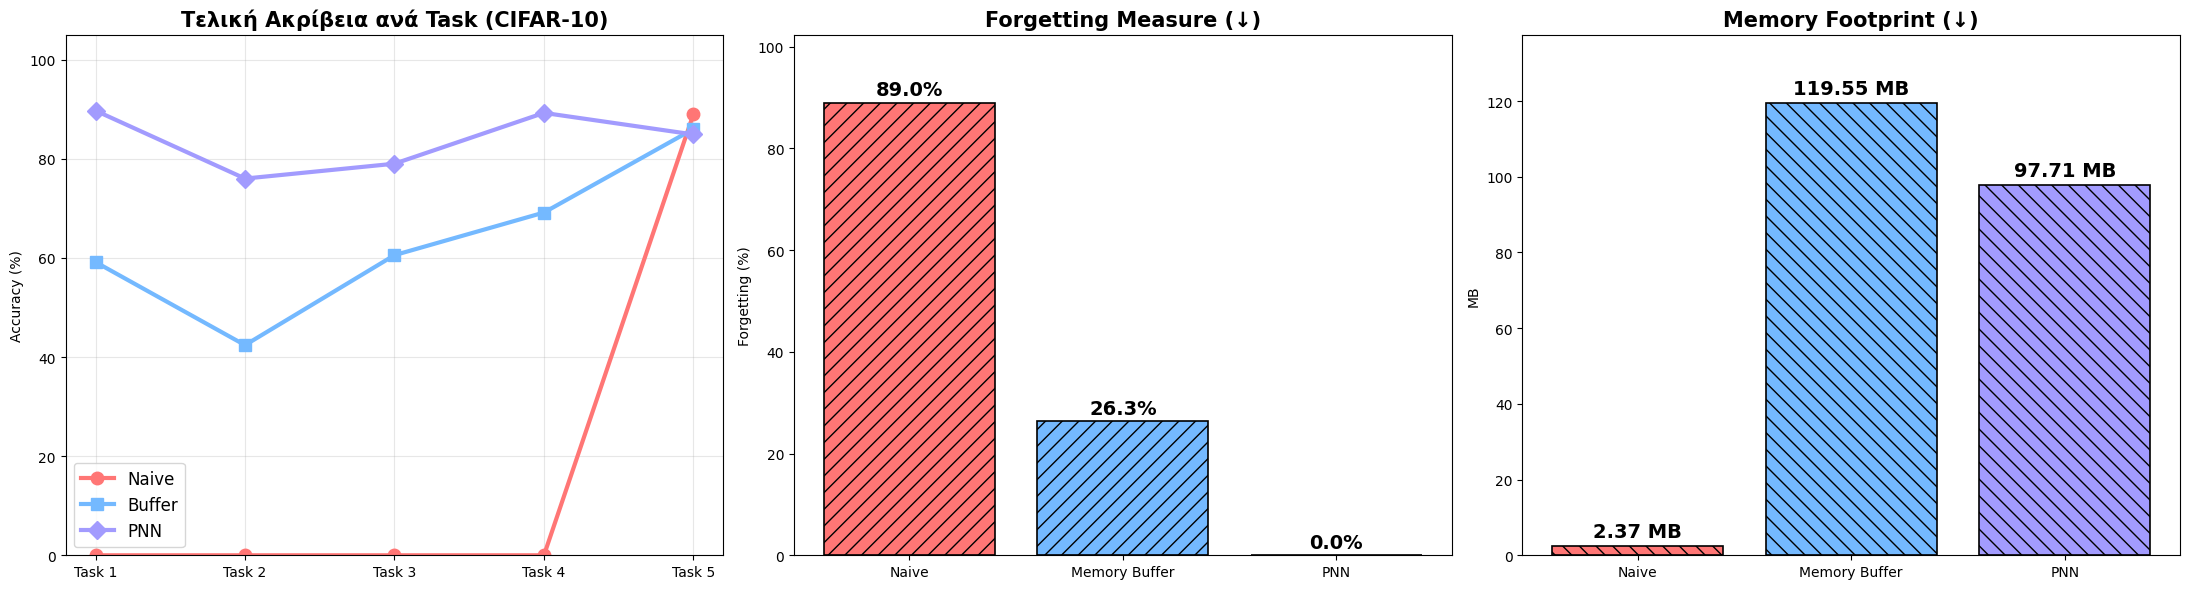

In [12]:
def pad_accuracies(acc_matrix):
    padded = []
    for row in acc_matrix:
        padded_row = list(row) + [np.nan] * (5 - len(row))
        padded.append(padded_row)
    return padded

f_naive = pad_accuracies(naive_acc_matrix)[-1]
f_buffer = pad_accuracies(buffer_acc_matrix)[-1]
f_pnn = pad_accuracies(pnn_acc_matrix)[-1]

forg_naive = calculate_forgetting(pad_accuracies(naive_acc_matrix))
forg_buffer = calculate_forgetting(pad_accuracies(buffer_acc_matrix))
forg_pnn = calculate_forgetting(pad_accuracies(pnn_acc_matrix))

# Υπολογισμός Μνήμης
cls_mb = (sum(p.numel() for p in CNNClassifier().parameters()) * 4) / (1024 ** 2)
mem_naive = cls_mb
# 5 tasks * 1000 images * 3 channels * 32x32 pixels * 4 bytes
mem_buffer = cls_mb + ((5000 * 2 * 3 * 32 * 32 * 4) / (1024 ** 2))
mem_pnn = (sum(p.numel() for p in pnn_model.parameters()) * 4) / (1024 ** 2)

# --- PLOTS ΑΚΡΙΒΩΣ ΟΠΩΣ ΣΤΗΝ ΕΙΚΟΝΑ ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
methods = ['Naive', 'Memory Buffer', 'PNN']
colors = ['#ff7675', '#74b9ff', '#a29bfe']

# 1. Line Plot (Τελική Ακρίβεια ανά Task)
x_labels = ['Task 1', 'Task 2', 'Task 3', 'Task 4', 'Task 5']
axes[0].plot(x_labels, f_naive, marker='o', lw=3, ms=9, color=colors[0], label='Naive')
axes[0].plot(x_labels, f_buffer, marker='s', lw=3, ms=9, color=colors[1], label='Buffer')
axes[0].plot(x_labels, f_pnn, marker='D', lw=3, ms=9, color=colors[2], label='PNN')
axes[0].set_title('Τελική Ακρίβεια ανά Task (CIFAR-10)', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 105)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=12, loc='lower left')

# 2. Bar Plot (Forgetting Measure)
f_vals = [forg_naive, forg_buffer, forg_pnn]
axes[1].bar(methods, f_vals, color=colors, edgecolor='black', linewidth=1.2, hatch='//')
axes[1].set_title('Forgetting Measure (↓)', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Forgetting (%)')
axes[1].set_ylim(0, max(f_vals) * 1.15 if max(f_vals) > 0 else 105)
for i, v in enumerate(f_vals):
    axes[1].text(i, v + 1.5, f"{max(0, v):.1f}%", ha='center', fontweight='bold', fontsize=14)

# 3. Bar Plot (Memory Footprint)
m_vals = [mem_naive, mem_buffer, mem_pnn]
axes[2].bar(methods, m_vals, color=colors, edgecolor='black', linewidth=1.2, hatch='\\\\')
axes[2].set_title('Memory Footprint (↓)', fontsize=15, fontweight='bold')
axes[2].set_ylabel('MB')
axes[2].set_ylim(0, max(m_vals) * 1.15)
for i, v in enumerate(m_vals):
    axes[2].text(i, v + (max(m_vals)*0.02), f"{v:.2f} MB", ha='center', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()